# Gradient Boosting in Machine Learning

Gradient Boosting is one of the most powerful and widely used supervised learning algorithms. It belongs to the ensemble learning family, which combines multiple weak models to create a highly accurate predictive model.

---

## 1. Core Idea

The core philosophy of Gradient Boosting is **sequential optimization**. Instead of building models independently (like Bagging or Random Forests), Gradient Boosting builds trees sequentially.

Each new tree is trained to correct the specific mistakes (errors) made by the previous ensemble of trees. It does this by fitting the new model to the **residuals** (the differences between predicted and actual values) of the previous step.

---

## 2. What It Mainly Does

Gradient Boosting primarily minimizes a **Loss Function** (such as Mean Squared Error for regression or Log Loss for classification) by adding weak learners using a gradient descent-like procedure.

* **For Regression:** It predicts a continuous value by iteratively reducing the variance between actual and predicted values.
* **For Classification:** It predicts class probabilities by optimizing the log-likelihood of the classes.

---

## 3. Why Do We Need It?

While single decision trees are easy to interpret, they are highly prone to overfitting (high variance) or underfitting (high bias). We need Gradient Boosting because:

* **High Predictive Accuracy:** It consistently outperforms almost all other traditional machine learning algorithms on tabular data.
* **Flexibility:** It can optimize any differentiable loss function (custom loss functions can be plugged in).
* **Handles Complex Relationships:** It captures non-linear relationships, interactions between features, and handles missing data efficiently.

---

## 4. Mathematical Intuition

Let's look at the math behind Gradient Boosting for a regression problem with a dataset $(x_i, y_i)$ and a differentiable loss function $L(y, \hat{y})$.

### Step 1: Initialize the model with a constant value

The model starts with a baseline prediction $F_0(x)$, which is typically the value that minimizes the loss function across all training data. For Mean Squared Error (MSE), this is simply the mean of the target values:

$$F_0(x) = \arg\min_{\gamma} \sum_{i=1}^n L(y_i, \gamma)$$

### Step 2: Iterative Training (For $m = 1$ to $M$ trees)

For each tree $m$:

1. **Compute Pseudo-Residuals:** Calculate the negative gradient of the loss function with respect to the current model's predictions. This tells us the direction and magnitude of our error.

$$r_{im} = -\left[ \frac{\partial L(y_i, F_{m-1}(x_i))}{\partial F_{m-1}(x_i)} \right]$$



*(Note: For MSE, where $L = \frac{1}{2}(y - \hat{y})^2$, the pseudo-residual $r_{im}$ simplifies beautifully to just the actual residual: $y_i - F_{m-1}(x_i)$).*
2. **Fit a Weak Learner (Tree):** Train a base learner (e.g., a shallow decision tree) $h_m(x)$ to predict these pseudo-residuals $r_{im}$.
3. **Update the Model:** Add the new tree's predictions to the ensemble, scaled by a learning rate ($\nu$), to prevent overfitting:

$$F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)$$



### Step 3: Final Output

After $M$ iterations, the final boosted model is:


$$F_M(x) = F_0(x) + \sum_{m=1}^M \nu \cdot h_m(x)$$

---

## 5. How It Works: A Conceptual Example

Imagine you are trying to guess a person's weight (Actual: **80 kg**).

1. **Base Prediction ($F_0$):** Your initial guess is the average weight of the population, say **60 kg**.
* *Residual:* $80 - 60 =$ **$+20$ kg**.


2. **Tree 1 ($h_1$):** You build a small tree to predict the residual ($+20$). The tree predicts **$+15$ kg**.
* With a learning rate ($\nu = 0.1$), your updated prediction is: $60 + (0.1 \times 15) =$ **$61.5$ kg**.
* *New Residual:* $80 - 61.5 =$ **$+18.5$ kg**.


3. **Tree 2 ($h_2$):** The next tree is trained to predict the new residual ($+18.5$).
4. **Repeat:** This process continues for $M$ steps until the residuals shrink close to zero.

---

## 6. Implementation Code (Python)

Below is a clean, practical implementation using `scikit-learn` for both regression and classification.

```python
import numpy as np
from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, accuracy_score

# =====================================================================
# 1. GRADIENT BOOSTING REGRESSION EXAMPLE
# =====================================================================
# Generate synthetic regression data
X_reg, y_reg = make_regression(n_samples=500, n_features=10, noise=0.1, random_state=42)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Initialize and train the regressor
reg_model = GradientBoostingRegressor(
    n_estimators=100,      # Number of boosting stages (M)
    learning_rate=0.1,     # Shrinkage factor (nu)
    max_depth=3,           # Limit depth of weak learners
    random_state=42
)
reg_model.fit(X_train_r, y_train_r)

# Predict and Evaluate
y_pred_r = reg_model.predict(X_test_r)
mse = mean_squared_error(y_test_r, y_pred_r)
print(f"Regression Mean Squared Error: {mse:.4f}")


# =====================================================================
# 2. GRADIENT BOOSTING CLASSIFICATION EXAMPLE
# =====================================================================
# Generate synthetic classification data
X_clf, y_clf = make_classification(n_samples=500, n_features=10, n_classes=2, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# Initialize and train the classifier
clf_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
clf_model.fit(X_train_c, y_train_c)

# Predict and Evaluate
y_pred_c = clf_model.predict(X_test_c)
accuracy = accuracy_score(y_test_c, y_pred_c)
print(f"Classification Accuracy: {accuracy * 100:.2f}%")

```

> **Pro-Tip on Hyperparameters:** > * `n_estimators` and `learning_rate` are tightly coupled. If you decrease `learning_rate`, you should increase `n_estimators` to give the model enough steps to converge.
> * Keep `max_depth` low (usually between 3 and 6) to ensure individual trees remain weak learners, which prevents overfitting.
> 
> * Consider using early stopping (`early_stopping=True`) to automatically find the optimal number of trees based on validation performance. 

In [11]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, fetch_california_housing

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    r2_score
)


In [ ]:
data = fetch_california_housing(
    as_frame = True
)

X = data.data
y = data.target

print("Features: ", data.feature_names)
print("Target: ", data.target_names)

# Data shape
print("Data shape: ", X.shape)

# Check null values
print("Null values: ", X.isnull().sum())


X.head()


Features:  ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target:  ['MedHouseVal']
Data shape:  (20640, 8)
Null values:  MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [7]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)  

gbr = GradientBoostingRegressor(
    n_estimators = 100, 
    learning_rate = 0.1, 
    max_depth = 3,
    random_state = 42
)


gbr.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [9]:
pred = gbr.predict(X_test)


In [13]:
mse = mean_squared_error(y_test, pred)
print("Mean Squared Error: ", mse)

r2 = gbr.score(X_test, y_test)
print("R^2 Score: ", r2)



Mean Squared Error:  0.2939973248643864
R^2 Score:  0.7756446042829697


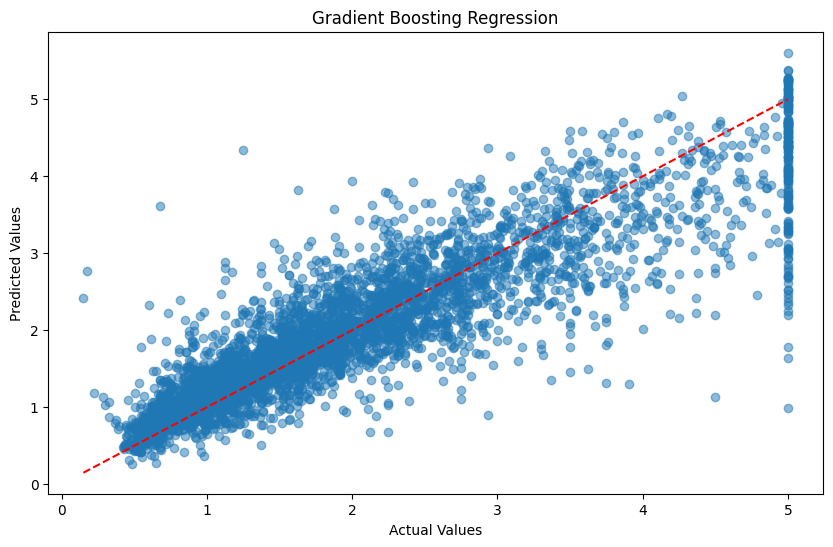

In [16]:
plt.figure(figsize = (10, 6))
plt.scatter(y_test, pred, alpha = 0.5)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Line for perfect predictions

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Gradient Boosting Regression")
plt.show()

In [17]:
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
results = []

for lr in learning_rates:
    model = GradientBoostingRegressor(
        n_estimators = 100,
        learning_rate = lr,
        max_depth = 3,
        random_state = 42
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    r2 = model.score(X_test, y_test)
    results.append((lr, mse, r2))
results_df = pd.DataFrame(results, columns = ['Learning Rate', 'MSE', 'R^2'])
print(results_df)

   Learning Rate       MSE       R^2
0           0.01  0.664288  0.493068
1           0.05  0.336981  0.742843
2           0.10  0.293997  0.775645
3           0.20  0.264565  0.798105
4           0.30  0.251349  0.808190
5           0.50  0.245879  0.812365
6           0.80  0.255472  0.805044
7           1.00  0.271127  0.793098


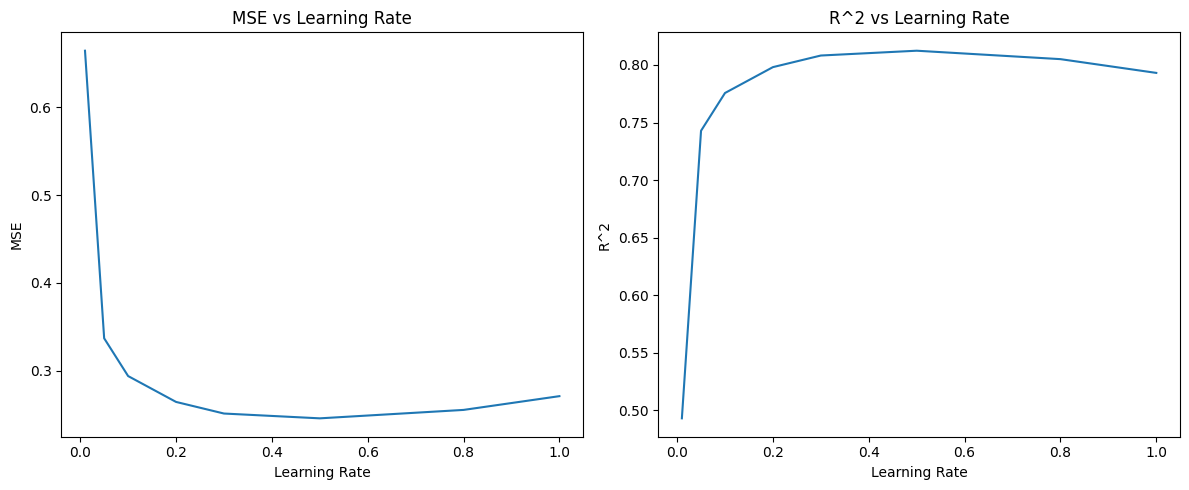

In [18]:
# plotting the results
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
sns.lineplot(x = 'Learning Rate', y = 'MSE', data = results_df)
plt.title("MSE vs Learning Rate")
plt.subplot(1, 2, 2)
sns.lineplot(x = 'Learning Rate', y = 'R^2', data = results_df)
plt.title("R^2 vs Learning Rate")
plt.tight_layout()
plt.show()

In [19]:
# effect of tree depth 

depths = range(1, 11)
results_depth = []

for depth in depths:
    model = GradientBoostingRegressor(
        n_estimators = 100,
        learning_rate = 0.1,
        max_depth = depth,
        random_state = 42
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    r2 = model.score(X_test, y_test)
    results_depth.append((depth, mse, r2))

results_depth_df = pd.DataFrame(results_depth, columns = ['Tree Depth', 'MSE', 'R^2'])
print(results_depth_df) 

   Tree Depth       MSE       R^2
0           1  0.489272  0.626627
1           2  0.344798  0.736878
2           3  0.293997  0.775645
3           4  0.259494  0.801975
4           5  0.247651  0.811013
5           6  0.229891  0.824566
6           7  0.217428  0.834076
7           8  0.215741  0.835364
8           9  0.215167  0.835802
9          10  0.225994  0.827540


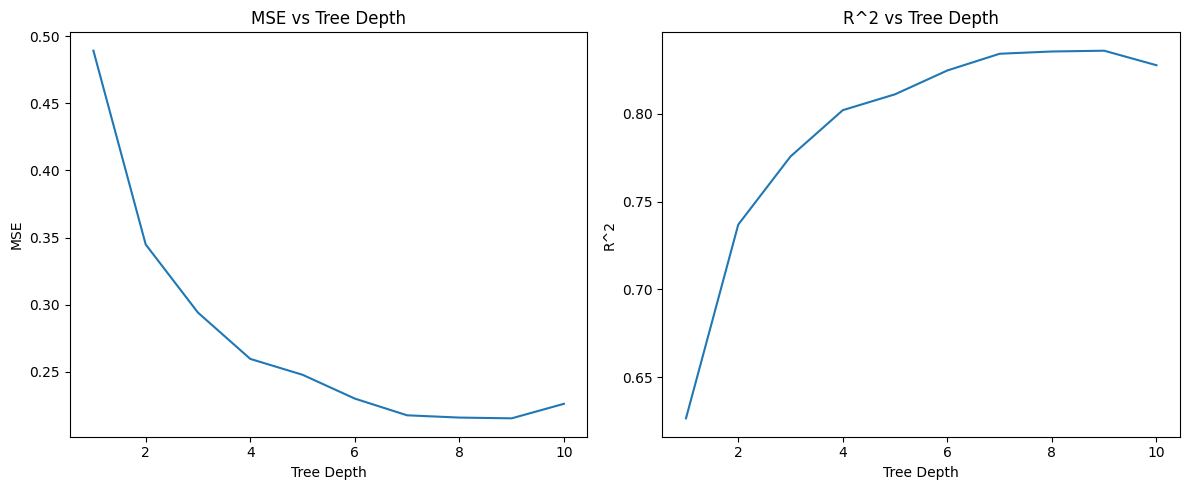

In [20]:
# plot 
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
sns.lineplot(x = 'Tree Depth', y = 'MSE', data = results_depth_df)
plt.title("MSE vs Tree Depth")
plt.subplot(1, 2, 2)
sns.lineplot(x = 'Tree Depth', y = 'R^2', data = results_depth_df)
plt.title("R^2 vs Tree Depth")
plt.tight_layout()
plt.show()